# NYC Taxi Trip Duration — Exploratory Data Analysis & Data Cleaning

Orginal data set:
https://www.kaggle.com/datasets/yasserh/nyc-taxi-trip-duration?utm_source=chatgpt.com

Author of orginal dataset:
https://www.kaggle.com/yasserh

#### About dataset:
The competition dataset is based on the 2016 NYC Yellow Cab trip record data made available in Big Query on Google Cloud Platform. The data was originally published by the NYC Taxi and Limousine Commission (TLC). The data was sampled and cleaned for the purposes of this playground competition. Based on individual trip attributes, participants should predict the duration of each trip in the test set.

#### Columns
- id - a unique identifier for each trip

- vendor_id - a code indicating the provider associated with the trip record

- pickup_datetime - date and time when the meter was engaged

- dropoff_datetime - date and time when the meter was disengaged

- passenger_count - the number of passengers in the vehicle (driver entered value)

- pickup_longitude - the longitude where the meter was engaged

- pickup_latitude - the latitude where the meter was engaged

- dropoff_longitude - the longitude where the meter was disengaged

- dropoff_latitude - the latitude where the meter was disengaged

- store_and_fwd_flag - This flag indicates whether the trip record was held in vehicle memory before sending to the vendor because the vehicle did not have a connection to the server - Y=store and forward; N=not a store and forward trip

- trip_duration - duration of the trip in seconds

## Dataset developed for model training

- passenger_count - Number of passengers in the taxi ride

- pickup_longitude - Longitude coordinate of pickup location

- pickup_latitude - Latitude coordinate of pickup location

- dropoff_longitude - Longitude coordinate of dropoff location

- dropoff_latitude - Latitude coordinate of dropoff location

- trip_duration_seconds - Target variable representing trip duration in seconds

- distance_km - Calculated trip distance using the Haversine formula

- pickup_hour - Hour of the day when the trip started

- pickup_weekday - Day of the week extracted from pickup timestamp

- is_weekend - Binary indicator specifying whether the trip occurred during a weekend

- pickup_month - Month extracted from pickup timestamp for seasonal analysis

- hour_sin - Cyclic sine transformation of pickup hour

- hour_cos - Cyclic cosine transformation of pickup hour

- bearing - Directional angle between pickup and dropoff coordinates representing route orientation

### My EDA analysis of the original dataset

https://krzysztofzakrzewski.github.io/portfolio/NYC_EDA/

# Goals of analis:

- Train ML model to predict 'trip_duration'
- Reduce model size below the previous 1.3 GB version while maintaining comparable predictive accuracy.

### Large-Scale Training Considerations

Previous large-scale experiments on the full 1.4 million record dataset achieved strong predictive performance, but also proved highly resource-intensive and more difficult to reproduce consistently across different hardware configurations. At the same time, the full-scale training process served as a practical computational stress test for large ensemble-based machine learning workflows.

In [5]:
# Imports

import pandas as pd
import numpy as np
import re
from IPython.display import Markdown
from IPython.display import Markdown, display
# from itables import show
import plotly.express as px
from plotly.subplots import make_subplots
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from collections import Counter

import joblib

#pyCaret
from pycaret.regression import (
    setup,
    compare_models,
    create_model,
    plot_model,
    evaluate_model,
    predict_model,
    pull,
    finalize_model,
    save_model
)

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

## 1. Technial Overview

Set the number to a readable format (not Scientific Notation (-6.133553e+01))

In [6]:
pd.set_option("display.float_format", "{:.6f}".format)

### 1.1 Reducing the sample to 200,000 from 1.4M

In [8]:
df_read = pd.read_csv('data_sample/NYC_200K_sampled.csv')
df = df_read.copy()
df = df.sample(200000, random_state=42)

### 1.2 Basic data info

In [33]:
info_df = pd.DataFrame({
    'Column': df.columns,
    "Duplicates": df.duplicated().sum(),
    'Non-null': df.notnull().sum().values,
    'Missing Values': df.isna().sum().values,
    'Percentage of Missing Values': (df.isna().sum()*100/df.notnull().sum()).values,
    'Unique Values': df.nunique().values,
    'Data Type': df.dtypes.values,
})

info_df

,Column,Duplicates,Non-null,Missing Values,Percentage of Missing Values,Unique Values,Data Type
0,id,0,200000,0,0.000000,200000,object
1,vendor_id,0,200000,0,0.000000,2,int64
2,pickup_datetime,0,200000,0,0.000000,198515,object
3,dropoff_datetime,0,200000,0,0.000000,198550,object
4,passenger_count,0,200000,0,0.000000,7,int64
5,pickup_longitude,0,200000,0,0.000000,14345,float64
6,pickup_latitude,0,200000,0,0.000000,30506,float64
7,dropoff_longitude,0,200000,0,0.000000,18831,float64
8,dropoff_latitude,0,200000,0,0.000000,37671,float64
9,store_and_fwd_flag,0,200000,0,0.000000,2,object


### 1.3 Describe of numeric columns

In [34]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
vendor_id,200000.000000,1.533955,0.498847,1.000000,1.000000,2.000000,2.000000,2.000000
passenger_count,200000.000000,1.657665,1.306717,0.000000,1.000000,1.000000,2.000000,6.000000
pickup_longitude,200000.000000,-73.973791,0.037313,-74.726715,-73.991913,-73.981750,-73.967506,-73.477310
pickup_latitude,200000.000000,40.751109,0.027725,40.099789,40.737461,40.754211,40.768425,40.899120
dropoff_longitude,200000.000000,-73.973670,0.035008,-74.663132,-73.991295,-73.979797,-73.963295,-73.324074
dropoff_latitude,200000.000000,40.751995,0.031948,40.153744,40.736053,40.754631,40.769901,41.115879
trip_duration,200000.000000,826.788885,611.436327,11.000000,399.000000,662.000000,1069.000000,4139.000000
trip_duration_seconds,200000.000000,826.788885,611.436327,11.000000,399.000000,662.000000,1069.000000,4139.000000
distances,200000.000000,0.035297,0.041464,0.000946,0.012770,0.021356,0.038470,0.833480
distance_km,200000.000000,3.425339,3.840058,0.100161,1.249670,2.108395,3.879134,75.291055


#### Summary of Technical Overview

- The original dataset contained 1,437,931 observations and was later reduced to a representative subset of 200,000 records for efficient model development and experimentation. The sampled dataset contained no missing values or duplicated records, providing a stable foundation for machine learning preprocessing and regression modeling.

- The id column will be removed because it serves only as a unique identifier and carries no predictive value.

- The trip_duration and trip_duration_seconds columns contain identical information. Only trip_duration_seconds will be preserved as the regression target.

- The dropoff_datetime column will be removed to prevent target leakage, since trip duration is directly related to the final trip timestamp.

- The km_per_hour feature will also be removed because it is mathematically derived from the target variable and would introduce severe data leakage.

- The distances and distance_km columns represent the same information in different units. Only distance_km will be preserved due to better interpretability.

- After previous EDA and cleaning stages, the dataset appears coherent, physically realistic, and ready for baseline regression modeling using PyCaret.

## 2. PyCaret Competytion

In [35]:
df = df.drop(
    columns=[
        'id',
        'dropoff_datetime',
        'trip_duration',
        'distances',
        'km_per_hour'
    ]
)

In [36]:
df.head()

,vendor_id,pickup_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration_seconds,distance_km,pickup_hour
233434,1,2016-02-25 07:10:58,2,-73.964951,40.791225,-73.954437,40.765369,N,956.000000,3.008260,7
456843,1,2016-06-12 14:19:28,1,-73.994171,40.751080,-73.988159,40.727852,N,722.000000,2.632003,14
232309,2,2016-04-24 01:10:54,3,-73.987350,40.733181,-73.952370,40.776569,N,671.000000,5.653161,1
531585,1,2016-02-16 09:05:53,2,-73.953751,40.785030,-73.971619,40.766273,N,1097.000000,2.571727,9
1140905,1,2016-01-08 09:40:33,1,-73.978348,40.748314,-73.782074,40.644276,N,1524.000000,20.189915,9


In [37]:
setup(
    data=df,
    target='trip_duration_seconds',
    session_id=123,
    fold=3
)

,Description,Value
0,Session id,123
1,Target,trip_duration_seconds
2,Target type,Regression
3,Original data shape,"(200000, 11)"
4,Transformed data shape,"(200000, 11)"
5,Transformed train set shape,"(140000, 11)"
6,Transformed test set shape,"(60000, 11)"
7,Numeric features,8
8,Categorical features,2
9,Preprocess,True


In [38]:
best_model = compare_models()

,,
,,
Initiated,. . . . . . . . . . . . . . . . . .,23:37:42
Status,. . . . . . . . . . . . . . . . . .,Loading Estimator
Estimator,. . . . . . . . . . . . . . . . . .,Linear Regression


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
ada,AdaBoost Regressor,424.9516,328682.5351,573.0188,0.1261,0.7339,0.9216,2.0667
lightgbm,Light Gradient Boosting Machine,442.4056,356135.8224,596.6872,0.0528,0.7537,0.9399,60.0433
et,Extra Trees Regressor,446.3387,360520.8631,600.3442,0.0410,0.7599,0.9547,1.2533
knn,K Neighbors Regressor,447.9058,363224.3854,602.5558,0.0340,0.7648,0.9648,0.4267
gbr,Gradient Boosting Regressor,447.4608,364622.8077,603.8015,0.0301,0.7635,0.9594,5.8767
rf,Random Forest Regressor,466.5535,369120.5113,607.1986,0.0186,0.7875,1.0408,4.0967
lar,Least Angle Regression,451.3132,374281.8360,611.7772,0.0043,0.7693,0.9665,0.5500
par,Passive Aggressive Regressor,451.6514,374305.4988,611.7970,0.0043,0.7698,0.9683,0.4267
ridge,Ridge Regression,451.3152,374284.5371,611.7795,0.0043,0.7693,0.9665,0.5533
lr,Linear Regression,451.3132,374281.8360,611.7772,0.0043,0.7693,0.9665,0.7033


### Initial ML Baseline Conclusions

- Initial regression experiments using PyCaret confirmed that the taxi trip duration problem is highly nonlinear and difficult to model using simple linear approaches.

- Tree-based ensemble models such as AdaBoost, Extra Trees, Random Forest, and LightGBM consistently outperformed linear regression algorithms, indicating that spatial and temporal interactions play a significant role in predicting trip duration.

- During the initial baseline stage, the best-performing model achieved approximately R² ≈ 0.13 without advanced temporal or directional feature engineering. This suggested that the dataset contained meaningful predictive structure, although the available features were still limited.

- At this stage, the models primarily relied on:
    - pickup and dropoff coordinates,
    - approximate travel distance,
    - and basic hourly temporal information.

- To improve predictive performance, additional feature engineering techniques were later implemented, including:
    - weekday and weekend indicators,
    - seasonal and monthly patterns,
    - rush-hour-related temporal features,
    - cyclic temporal encoding using sine and cosine transformations,
    - and directional movement features based on trip bearing.

- The results also confirmed that the previous EDA and cleaning stages successfully removed major inconsistencies and leakage sources, allowing the models to produce realistic baseline performance rather than artificially inflated metrics.

## 3. Imrovments

### 3.1 weekday and weekend feature

In [39]:
# day of the week
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])

df['pickup_weekday'] = (
    df['pickup_datetime']
    .dt.dayofweek
)

# weekend flag
df['is_weekend'] = (
    df['pickup_weekday'] >= 5
).astype(int)

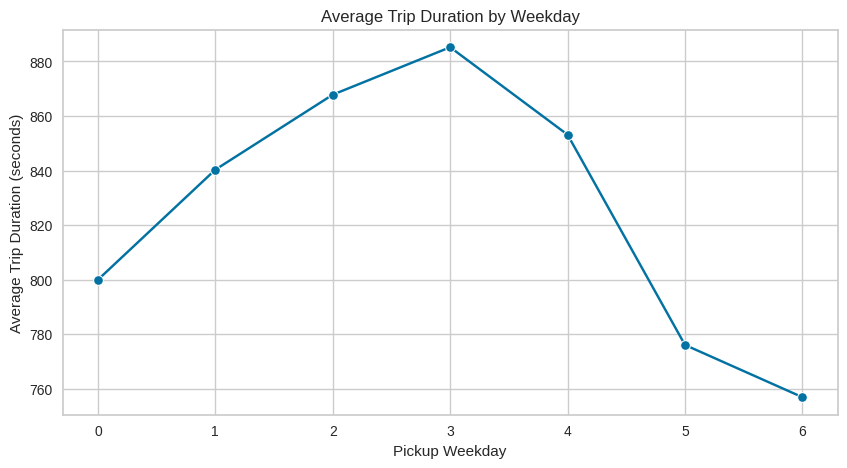

In [40]:
weekday_duration = (
    df.groupby('pickup_weekday')['trip_duration_seconds']
    .mean()
    .reset_index()
)

plt.figure(figsize=(10, 5))

sns.lineplot(
    data=weekday_duration,
    x='pickup_weekday',
    y='trip_duration_seconds',
    marker='o'
)

plt.title('Average Trip Duration by Weekday')
plt.xlabel('Pickup Weekday')
plt.ylabel('Average Trip Duration (seconds)')

plt.show()

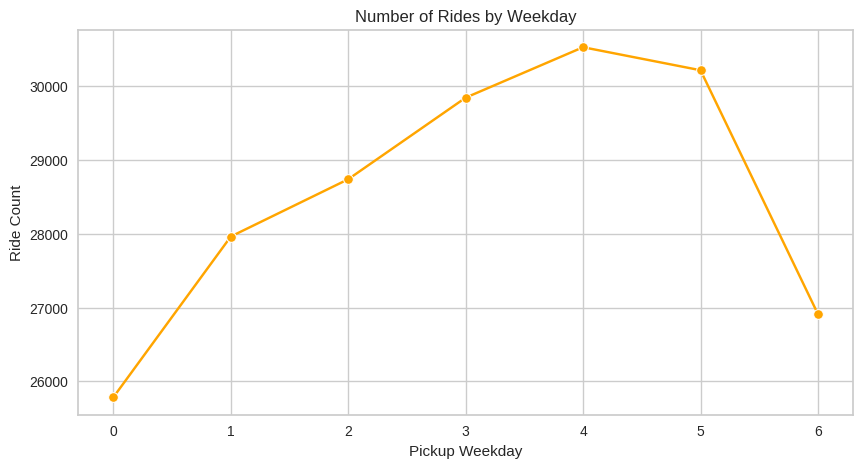

In [41]:
weekday_rides = (
    df.groupby('pickup_weekday')
    .size()
    .reset_index(name='rides')
)

plt.figure(figsize=(10, 5))

sns.lineplot(
    data=weekday_rides,
    x='pickup_weekday',
    y='rides',
    marker='o',
    color='orange'
)

plt.title('Number of Rides by Weekday')
plt.xlabel('Pickup Weekday')
plt.ylabel('Ride Count')

plt.show()

#### Weekday Pattern Conclusions

- Both ride frequency and average trip duration exhibit clear weekday-dependent patterns, confirming that transportation behavior changes significantly throughout the week.

- The highest ride activity occurs between Thursday and Friday, suggesting increased commuting, business activity, and evening transportation demand during late weekdays.

- Weekend periods, especially Sunday, show a noticeable decrease in total ride volume together with shorter average trip durations.

- The reduced trip duration observed during weekends likely reflects lower traffic congestion and smoother transportation flow across the NYC metropolitan area.

- These observations strongly support preserving both pickup_weekday and is_weekend as meaningful temporal features for regression modeling.

### 3.2 Seasonal/monthly patterns,

In [42]:
df['pickup_month'] = (
    df['pickup_datetime']
    .dt.month
)

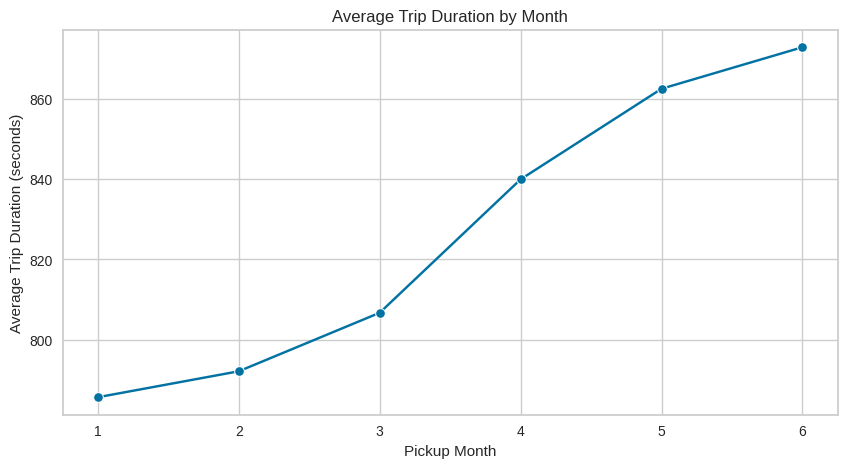

In [43]:
hour_analysis = (
    df.groupby('pickup_month')['trip_duration_seconds']
    .mean()
    .reset_index()
)

plt.figure(figsize=(10, 5))

sns.lineplot(
    data=hour_analysis,
    x='pickup_month',
    y='trip_duration_seconds',
    marker='o'
)

plt.title('Average Trip Duration by Month')
plt.xlabel('Pickup Month')
plt.ylabel('Average Trip Duration (seconds)')

plt.show()

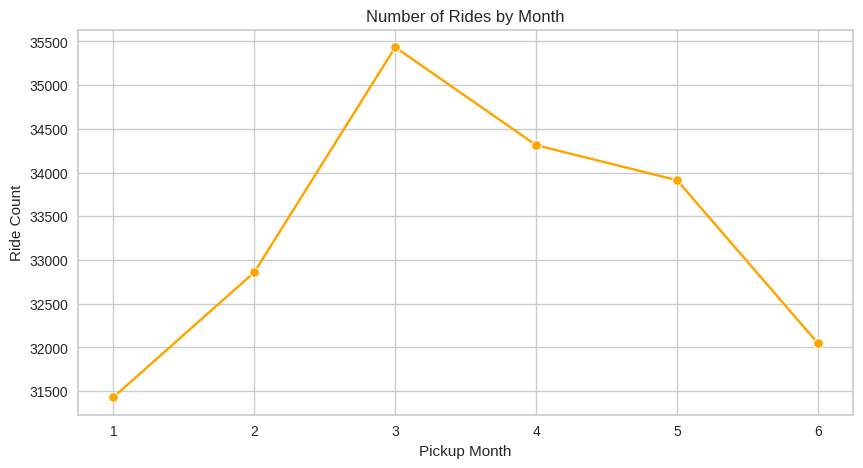

In [44]:
hour_counts = (
    df.groupby('pickup_month')
    .size()
    .reset_index(name='rides')
)

plt.figure(figsize=(10, 5))

sns.lineplot(
    data=hour_counts,
    x='pickup_month',
    y='rides',
    marker='o',
    color="Orange",
)

plt.title('Number of Rides by Month')
plt.xlabel('Pickup Month')
plt.ylabel('Ride Count')

plt.show()

- Monthly patterns indicate the presence of seasonal temporal structure within the dataset.
- Average trip duration gradually increases between January and June despite fluctuations in total ride volume.
- This suggests that trip duration is influenced not only by ride frequency but also by broader seasonal transportation dynamics.
- The observed patterns support preserving pickup_month as a potentially useful regression feature.

### 3.3 Rush-houers

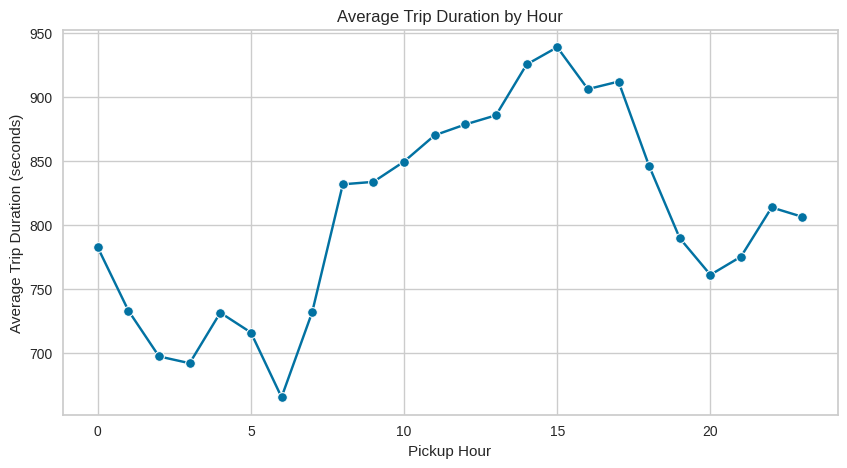

In [45]:
hour_analysis = (
    df.groupby('pickup_hour')['trip_duration_seconds']
    .mean()
    .reset_index()
)

plt.figure(figsize=(10, 5))

sns.lineplot(
    data=hour_analysis,
    x='pickup_hour',
    y='trip_duration_seconds',
    marker='o'
)

plt.title('Average Trip Duration by Hour')
plt.xlabel('Pickup Hour')
plt.ylabel('Average Trip Duration (seconds)')

plt.show()

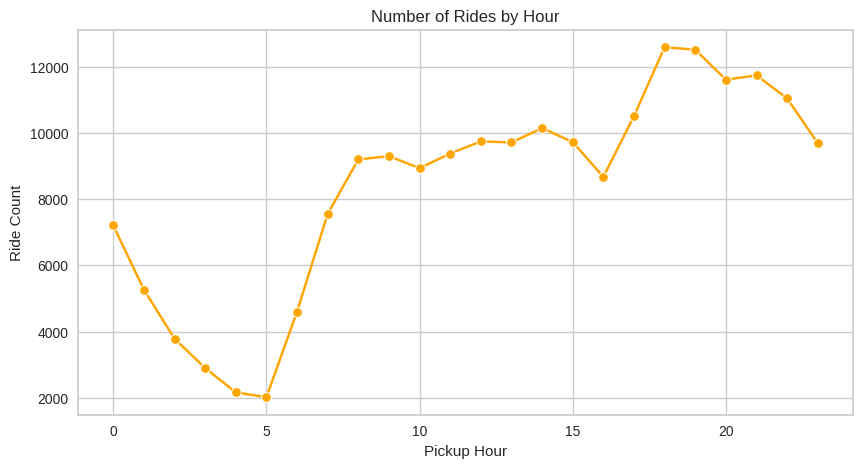

In [46]:
hour_counts = (
    df.groupby('pickup_hour')
    .size()
    .reset_index(name='rides')
)

plt.figure(figsize=(10, 5))

sns.lineplot(
    data=hour_counts,
    x='pickup_hour',
    y='rides',
    marker='o',
    color="Orange",
)

plt.title('Number of Rides by Hour')
plt.xlabel('Pickup Hour')
plt.ylabel('Ride Count')

plt.show()

- NYC transportation behavior strongly depends on time of day.

- Traffic congestion and ride demand vary substantially throughout the day.

- Both trip duration and ride frequency exhibit clear temporal patterns, confirming that temporal feature engineering is likely important for improving regression - performance.

### 3.4 Cyclic temporal encoding

In [47]:
df['hour_sin'] = np.sin(
    2 * np.pi * df['pickup_hour'] / 24
)

df['hour_cos'] = np.cos(
    2 * np.pi * df['pickup_hour'] / 24
)

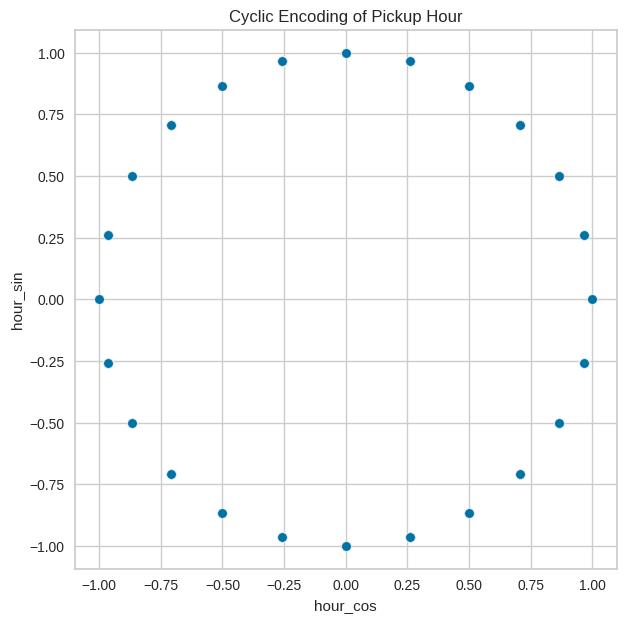

In [48]:
plt.figure(figsize=(7, 7))

sns.scatterplot(
    data=df.sample(1000, random_state=42),
    x='hour_cos',
    y='hour_sin',
    alpha=0.7
)

plt.title('Cyclic Encoding of Pickup Hour')
plt.xlabel('hour_cos')
plt.ylabel('hour_sin')

plt.axis('equal')

plt.show()

Cyclic encoding transforms linear temporal values into circular representations, allowing the model to correctly interpret cyclical relationships between hours such as 23:00 and 00:00.

### 3.5 Directional movement features (bearing/route orientation).

In [49]:
df['bearing'] = np.degrees(
    np.arctan2(
        df['dropoff_longitude'] - df['pickup_longitude'],
        df['dropoff_latitude'] - df['pickup_latitude']
    )
)

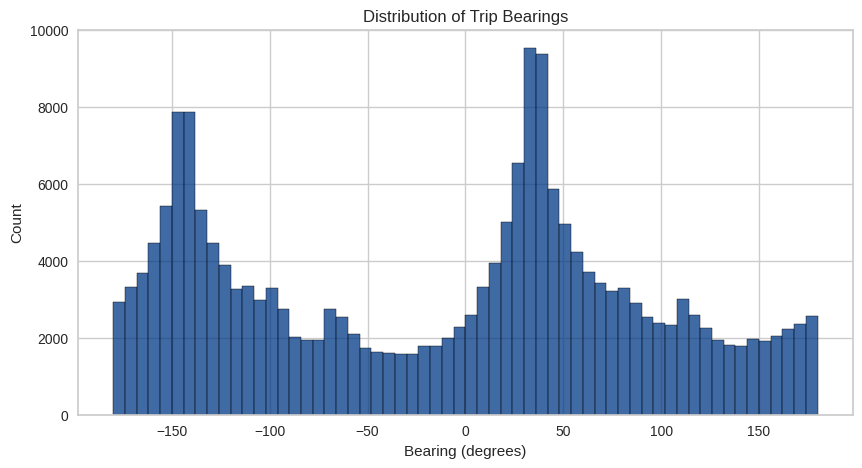

In [50]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df['bearing'],
    bins=60,
    color='#003884'
)

plt.title('Distribution of Trip Bearings')
plt.xlabel('Bearing (degrees)')
plt.ylabel('Count')

plt.show()

Bearing features provide directional information about taxi movement between pickup and dropoff locations. This allows the model to distinguish between trips of similar distance but different spatial orientation, potentially capturing traffic asymmetries and transportation corridor effects within NYC.

<img src="NYC_and_data.jpg" width="800">

The bearing distribution also revealed a strong directional structure within the dataset. Two dominant movement orientations appear around approximately +45° and -135°, corresponding to northeast and southwest directional flows. This pattern aligns closely with the diagonal street orientation of Manhattan and suggests that a large portion of taxi traffic follows the natural geometric structure of the NYC road network.

The observed directional symmetry indicates that the engineered bearing feature is not random mathematical noise but instead captures meaningful transportation behavior. Trips moving through Manhattan corridors, airport routes, bridges, and major commuting paths likely contribute to these dominant directional patterns, potentially providing additional predictive information for trip duration modeling.

## 4. Repeated model comparison after implementing improvements

removing the following columns from df:
- 'pickup_datetime',
because we already have information from this column in the dataset

In [51]:
df = df.drop(
    columns=[

        'pickup_datetime',

    ]
)


In [52]:
setup(
    data=df,
    target='trip_duration_seconds',
    session_id=123,
    fold=3
)

,Description,Value
0,Session id,123
1,Target,trip_duration_seconds
2,Target type,Regression
3,Original data shape,"(200000, 16)"
4,Transformed data shape,"(200000, 16)"
5,Transformed train set shape,"(140000, 16)"
6,Transformed test set shape,"(60000, 16)"
7,Numeric features,14
8,Categorical features,1
9,Preprocess,True


In [53]:
best_model = compare_models()

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
lightgbm,Light Gradient Boosting Machine,185.1296,76725.8031,276.9941,0.7959,0.3459,0.2914,61.2767
rf,Random Forest Regressor,189.7527,79449.1056,281.8663,0.7886,0.3558,0.3070,7.1567
et,Extra Trees Regressor,193.9968,81526.7869,285.5268,0.7831,0.3661,0.3194,3.3900
gbr,Gradient Boosting Regressor,204.8922,91387.2163,302.3025,0.7569,0.3789,0.3270,7.1667
knn,K Neighbors Regressor,248.5818,122133.1432,349.4718,0.6751,0.4760,0.4463,0.3300
lr,Linear Regression,261.4360,136846.8788,369.9261,0.6359,0.4934,0.4882,0.0933
ridge,Ridge Regression,261.4547,136847.5870,369.9270,0.6359,0.4935,0.4883,0.0900
br,Bayesian Ridge,261.4432,136846.9568,369.9262,0.6359,0.4934,0.4882,0.1000
lar,Least Angle Regression,264.5404,138837.9679,372.6079,0.6306,0.5012,0.4922,0.0900
lasso,Lasso Regression,265.8312,139827.3295,373.9326,0.6280,0.5023,0.5050,0.0967


### Feature Engineering Conclusions

- The introduction of temporal and directional feature engineering resulted in a dramatic improvement in model performance. Initial baseline models achieved approximately R² ≈ 0.13, while the enhanced feature set increased performance to nearly R² ≈ 0.80.

- Tree-based ensemble models benefited the most from the newly engineered features. LightGBM achieved the highest overall score during the final PyCaret comparison stage, followed closely by Random Forest and Extra Trees, further confirming the highly nonlinear nature of urban transportation behavior.
- Temporal features such as:
    - pickup_weekday,
    - is_weekend,
    - pickup_month,
    - and cyclic hour encoding (hour_sin, hour_cos)

    significantly improved the model’s ability to capture recurring transportation patterns and time-dependent traffic dynamics.

- The engineered bearing feature introduced meaningful directional information into the model. The observed directional distributions aligned closely with the geometric orientation of Manhattan and major NYC transportation corridors, suggesting that route orientation contributes directly to trip duration variability.

- One of the most interesting observations was the dramatic improvement of even simple linear models after feature engineering. Linear Regression improved from approximately R² ≈ 0.00 during the baseline stage to over R² ≈ 0.63, indicating that the engineered features substantially increased the structural interpretability of the dataset.

- Although LightGBM achieved the highest final PyCaret score on the 200k subset, Random Forest was retained as the final model because previous large-scale experiments on the full 1.4 million record dataset produced nearly identical performance and feature importance distributions. Maintaining the existing 

- Although LightGBM achieved the highest final PyCaret score on the 200k subset, Random Forest was retained as the final model because previous experiments on the full 1.4 million record dataset produced nearly identical performance and feature importance distributions. Maintaining the existing Random Forest pipeline will preserve workflow consistency while potentially reducing overall model size and computational requirements.

- The final results strongly suggest that feature engineering contributed more to predictive performance than model complexity itself. Spatial understanding, temporal structure, and directional movement patterns proved essential for accurately modeling NYC taxi trip duration behavior.

## 5. Sci-kitlear modeling

### 5.1. Preper dataset X/y

In [54]:
df['store_and_fwd_flag'] = (
    df['store_and_fwd_flag']
    .map({
        'N': 0,
        'Y': 1
    })
)

In [55]:
df_tune = df

In [56]:
X = df_tune.drop(columns=['trip_duration_seconds'])
y = df_tune['trip_duration_seconds']

### 5.2. train/test split

In [57]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

### 5.3. model

In [58]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

### 5.4. training

In [59]:
rf.fit(X_train, y_train)

RandomForestRegressor(n_jobs=-1, random_state=42)

### 5.5. predictions

In [60]:
y_pred = rf.predict(X_test)

### 5.6. metrics

In [61]:
print('MAE:', mean_absolute_error(y_test, y_pred))
print('RMSE:', np.sqrt(mean_squared_error(y_test, y_pred)))
print('R2:', r2_score(y_test, y_pred))

MAE: 184.1738335
RMSE: 272.91297098862856
R2: 0.8009575790208302


### Random Forest Regression Conclusions

- The manually implemented Random Forest model successfully reproduced the earlier PyCaret benchmark results, achieving approximately:
    - MAE ≈ 184 seconds
    - RMSE ≈ 273 seconds
    - R² ≈ 0.80

- An average prediction error of roughly 3 minutes is considered a strong result for a real-world urban transportation dataset, especially given the complexity and unpredictability of NYC traffic behavior.

- The remaining prediction errors are likely influenced by:
    - traffic congestion variability,
    - different street structures and traffic light density,
    - bridge and tunnel bottlenecks,
    - airport-related routes,
    - and remaining unusual trip patterns.

- Even trips with similar geographic distance may require significantly different travel times depending on route orientation, road network complexity, and time-dependent congestion patterns.

- The strong model performance confirms that the engineered temporal and spatial features successfully captured a large portion of the transportation dynamics present within the dataset.

- The results also demonstrate that feature engineering contributed substantially more to model quality than model complexity alone.

## 6 Tunnig model.

### 6.1 GridSearchCV

In [62]:
from sklearn.model_selection import GridSearchCV

Prametrs

param_grid = {
   
   'n_estimators': [100, 150],
   
   'max_depth': [10, 20, None],
   
   'min_samples_split': [2, 5],


}

In [63]:
param_grid = {
    'n_estimators': [100, 150],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
}

grid_search = GridSearchCV(
   
   estimator=rf,
   
   param_grid=param_grid,
   
   cv=3,
   
   scoring='r2',
   
   n_jobs=-1,
   
   verbose=2
)

In [64]:
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=2
)

In [66]:
grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 12 candidates, totalling 36 fits
[CV] END max_depth=10, min_samples_split=2, n_estimators=100; total time= 1.3min
[CV] END max_depth=10, min_samples_split=2, n_estimators=100; total time= 1.4min
[CV] END max_depth=10, min_samples_split=5, n_estimators=100; total time= 1.4min
[CV] END max_depth=10, min_samples_split=2, n_estimators=100; total time= 1.4min
[CV] END max_depth=10, min_samples_split=5, n_estimators=100; total time= 1.4min
[CV] END max_depth=10, min_samples_split=5, n_estimators=100; total time= 1.4min
[CV] END max_depth=10, min_samples_split=2, n_estimators=150; total time= 1.9min
[CV] END max_depth=10, min_samples_split=5, n_estimators=150; total time= 2.0min
[CV] END max_depth=10, min_samples_split=5, n_estimators=150; total time= 2.0min
[CV] END max_depth=10, min_samples_split=2, n_estimators=150; total time= 2.0min
[CV] END max_depth=10, min_samples_split=2, n_estimators=150; total time= 2.0min
[CV] END max_depth=10, min_samples_split=5, n_es

GridSearchCV(cv=3, estimator=RandomForestRegressor(n_jobs=-1, random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': [10, 20, None],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 150]},
             scoring='r2', verbose=2)

In [67]:
best_rf = grid_search.best_estimator_

### Parameters of the best tune model

In [68]:
print(grid_search.best_params_)

{'max_depth': None, 'min_samples_split': 5, 'n_estimators': 150}


### Scores of the best tune model

In [69]:
print(f'R2 score:{grid_search.best_score_}')

R2 score:0.79101288782164


The difference between the full 1.4 million record dataset (R² ≈ 0.7946) and the reduced 200k subset (R² ≈ 0.7910) remained minimal, suggesting that the sampled dataset successfully preserved the underlying statistical structure and predictive relationships present in the original data.

### Save model

In [70]:
joblib.dump(best_rf, 'models/random_forest_model_sample.pkl')

['models/random_forest_model_sample.pkl']

#### Size of the model ~887MB

## Feature importance dataframe

In [71]:
# Feature importance dataframe

feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_rf.feature_importances_
})

# Sort values
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance

,Feature,Importance
7,distance_km,0.685523
14,bearing,0.047188
5,dropoff_latitude,0.043590
13,hour_cos,0.036205
4,dropoff_longitude,0.035397
2,pickup_longitude,0.033711
3,pickup_latitude,0.029486
9,pickup_weekday,0.020728
8,pickup_hour,0.019114
12,hour_sin,0.018249


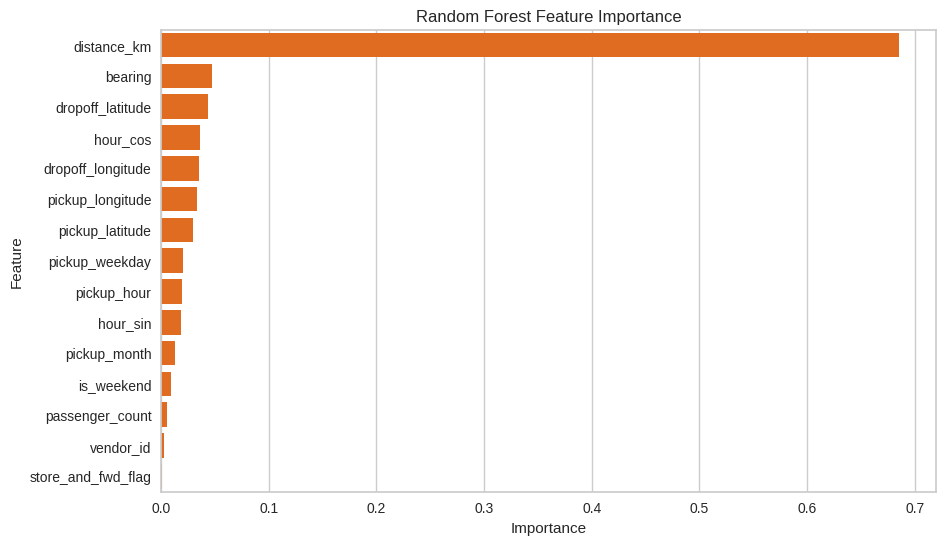

In [72]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance,
    x='Importance',
    y='Feature',
    color='#FF6600'
)

plt.title('Random Forest Feature Importance')

plt.show()

### Feature Importance Conclusions

- 'distance_km' was by far the most influential feature in the Random Forest model, dominating all other variables. This strongly confirms that trip distance remains the primary driver of taxi trip duration in NYC transportation dynamics.

- Directional movement (bearing) emerged as the second most important feature, indicating that route orientation contributes meaningful predictive information beyond simple geographic distance alone.

- Geographic coordinate features (pickup/dropoff latitude and longitude) also played an important role, suggesting that different NYC regions and transportation corridors exhibit distinct traffic behaviors and travel patterns.

- Temporal features such as:

    - pickup_hour,
    - cyclic time encoding (hour_sin, hour_cos),
    - pickup_weekday,
    - and pickup_month

    contributed moderate predictive value, confirming that traffic congestion and transportation efficiency vary across different times of day and weekly activity cycles.

- Features such as:

    - vendor_id,
    - store_and_fwd_flag,
    - and passenger_count

    showed minimal influence on prediction performance, suggesting that operational vendor differences contribute relatively little compared to spatial and temporal transportation structure.

- Despite their relatively weak contribution, these features were intentionally retained in the final modeling pipeline in order to experimentally verify whether the initial assumption regarding their limited predictive value was correct.

- One particularly interesting observation is that spatial understanding again proved more important than many traditional categorical transportation variables. The model relied primarily on:
    - where movement happens,
    - how far movement occurs,
    - and in which direction movement takes place.

#### Feature importance distributions remained highly consistent between the original 1.4 million record dataset and the reduced 200k subset. The near-identical ranking and contribution of spatial, temporal, and directional features confirmed that the sampled dataset successfully preserved the underlying transportation dynamics and predictive structure of the original data.

In [ ]:
# Interactive Prediction Playground

#   After uncommenting the playground section, users can manually provide their own custom trip
#   parameters and test the trained Random Forest model on new input data.

#   The playground allows experimentation with features such as:
#      - pickup and dropoff coordinates,
#      - trip distance,
#      - temporal information,
#       and directional movement values.

#  Based on the provided inputs, the model generates predicted
#  taxi trip duration values in both seconds and minutes,
#  allowing users to interact directly with the final
#  regression pipeline and observe how different
#  transportation conditions influence prediction results.

In [ ]:
# model = joblib.load('models/random_forest_model_sample.pkl')

In [ ]:
# from math import radians, sin, cos, sqrt, atan2, degrees


# # =====================================
# # DISTANCE FUNCTION
# # =====================================

# def calculate_distance(
#     pickup_latitude,
#     pickup_longitude,
#     dropoff_latitude,
#     dropoff_longitude
# ):

#     R = 6371

#     lat1 = radians(pickup_latitude)
#     lon1 = radians(pickup_longitude)

#     lat2 = radians(dropoff_latitude)
#     lon2 = radians(dropoff_longitude)

#     dlat = lat2 - lat1
#     dlon = lon2 - lon1

#     a = (
#         sin(dlat / 2) ** 2
#         + cos(lat1) * cos(lat2) * sin(dlon / 2) ** 2
#     )

#     c = 2 * atan2(sqrt(a), sqrt(1 - a))

#     return R * c


# # =====================================
# # BEARING FUNCTION
# # =====================================

# def calculate_bearing(
#     pickup_latitude,
#     pickup_longitude,
#     dropoff_latitude,
#     dropoff_longitude
# ):

#     lat1 = radians(pickup_latitude)
#     lat2 = radians(dropoff_latitude)

#     diff_long = radians(
#         dropoff_longitude - pickup_longitude
#     )

#     x = sin(diff_long) * cos(lat2)

#     y = (
#         cos(lat1) * sin(lat2)
#         - sin(lat1) * cos(lat2) * cos(diff_long)
#     )

#     initial_bearing = atan2(x, y)

#     initial_bearing = degrees(initial_bearing)

#     compass_bearing = (initial_bearing + 360) % 360

#     return compass_bearing


# # =====================================
# # RAW USER INPUT
# # =====================================

# vendor_id = 2
# passenger_count = 1

# pickup_longitude = -73.992155
# pickup_latitude = 40.767937

# dropoff_longitude = -73.964630
# dropoff_latitude = 40.765602

# store_and_fwd_flag = 0

# pickup_hour = 17
# pickup_weekday = 0
# pickup_month = 3


# # =====================================
# # AUTO FEATURE ENGINEERING
# # =====================================

# distance_km = calculate_distance(
#     pickup_latitude,
#     pickup_longitude,
#     dropoff_latitude,
#     dropoff_longitude
# )

# bearing = calculate_bearing(
#     pickup_latitude,
#     pickup_longitude,
#     dropoff_latitude,
#     dropoff_longitude
# )

# is_weekend = 1 if pickup_weekday >= 5 else 0

# hour_sin = np.sin(
#     2 * np.pi * pickup_hour / 24
# )

# hour_cos = np.cos(
#     2 * np.pi * pickup_hour / 24
# )


# # =====================================
# # FINAL MODEL INPUT
# # =====================================

# sample_trip = pd.DataFrame([{
#     'vendor_id': vendor_id,
#     'passenger_count': passenger_count,

#     'pickup_longitude': pickup_longitude,
#     'pickup_latitude': pickup_latitude,

#     'dropoff_longitude': dropoff_longitude,
#     'dropoff_latitude': dropoff_latitude,

#     'store_and_fwd_flag': store_and_fwd_flag,

#     'distance_km': distance_km,

#     'pickup_hour': pickup_hour,
#     'pickup_weekday': pickup_weekday,
#     'is_weekend': is_weekend,
#     'pickup_month': pickup_month,

#     'hour_sin': hour_sin,
#     'hour_cos': hour_cos,

#     'bearing': bearing
# }])


# print(sample_trip)

In [ ]:
# prediction = model.predict(sample_trip)

# print(f'Predicted trip duration: {prediction[0]:.2f} seconds')
# print(f'Predicted trip duration: {prediction[0] / 60:.2f} minutes')